# Replay do pipeline no B-8802B — o sistema inteiro rodando sobre jan/2025 a ago/2026

**Pergunta:** se o sistema (modelo de anomalia + monitor semanal + retreino) estivesse em produção desde jan/2025,
o que ele teria feito? Quando teria alertado, quando teria visto a mudança de conceito, quais modelos teria colocado
em produção, e com que sensibilidade a falhas?

**Como o replay funciona**
1. **jan/2025:** em produção está o modelo de 2022. O monitor semanal compara cada dia com a referência de 2022.
2. **Mudança de conceito:** o KS do monitor dispara no começo de jan/2025 (depois do reparo de 2022 o normal mudou).
   Supomos que a operação confirmou um **normal novo** a partir de **06/01/2025**.
3. **Retreino provisório:** com 1 mês do normal novo (06/02/2025) o pipeline (`scripts/retrain_pipeline.py
   --provisorio`) treina 12 candidatos, escolhe um e o passa pela bateria provisória; aprovado, entra em produção.
   Todo mês ele é refeito com tudo o que acumulou, até o de **12 meses** (06/01/2026), que fica até o fim dos dados
   (10/08/2026). As 12 etapas rodaram no ClearML (`scripts/replay_pipeline.py --remote`, task `28fb7c95`).
4. **Em cada período**, o modelo que estaria em produção gera os alertas (regra de 1 hora, persistência no tempo) e o
   monitor roda com os detectores do bundle dele (M6 KS, M7 dado congelado, M8 temperatura do mancal LA).

Nenhuma etapa usa dado posterior ao próprio treino para escolher o modelo. Para comparar, rodamos os mesmos dados com
o modelo antigo mantido (sem o pipeline) e com o modelo atual B-8802B-2025, que foi treinado com 2025 e escolhido
olhando jan–mai/2026, ou seja, com informação que o replay não teria. Todos com as mesmas regras de alarme.

In [1]:
import sys, json, shutil, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.dates as mdates
import torch
%config InlineBackend.figure_format = "retina"
warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists(): PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
DEP = PROJECT_ROOT / "deploy_v2/Transpetro"; sys.path.insert(0, str(DEP))
import simpred_inference as si
from transpetro_modelos.drift import monitor as mon
from transpetro_modelos.drift.detectors import CalibratedKSDetector
from transpetro_modelos.drift.residuo import ResidualLevelDetector

R = PROJECT_ROOT / "results/replay_pipeline"      # baixado com: scripts/replay_pipeline.py --baixar 28fb7c95e4df46b38782472e1837f857
DADOS = DEP / "B-8802B-2025/dados/2025_2026/data_2025-01-01_2026-08-10_raw.csv"
raw = si.carregar_dados(DADOS)
FIM = raw.index.max()
B_ANTIGO_ORIG = DEP / "B-8802B/modelos/model_2022-05-15_2022-07-21_VAE"
B_ATUAL = DEP / "B-8802B-2025/modelos/model_2025-01-01_2026-08-10_VAE"

# o modelo antigo com as MESMAS regras de alarme do pipeline (persistência 15 de 20 no tempo, regra de 1 h), numa cópia
B_ANTIGO = R / "modelo_2022_regras_novas"
if not B_ANTIGO.exists():
    shutil.copytree(B_ANTIGO_ORIG, B_ANTIGO)
alarm = json.loads((B_ANTIGO / "alarm.json").read_text())
alarm.update({"debounce_window": 20, "debounce_min": 15, "persistence_mode": "time", "persistence_step": "5min", "min_alert_hours": 1.0})
(B_ANTIGO / "alarm.json").write_text(json.dumps(alarm, indent=1, ensure_ascii=False))

resumo = pd.read_csv(R / "resumo.csv")
resumo[["etapa", "treino_fim", "aprovado", "candidato", "fp_val_pct", "falha_2022_dias", "normal_2022_pct", "sintetica_h"]].round(2)

,etapa,treino_fim,aprovado,candidato,fp_val_pct,falha_2022_dias,normal_2022_pct,sintetica_h
0,1,2025-02-06,True,l256-128-64_lat16_lr0.001_s0,0.0,2.05,5.04,15.08
1,2,2025-03-06,True,l128-64-32_lat16_lr0.0001_s1,0.0,1.88,4.74,12.50
2,3,2025-04-06,True,l128-64-32_lat16_lr0.0001_s2,0.0,1.90,2.65,16.08
3,4,2025-05-06,True,l128-64-32_lat16_lr0.001_s0,0.0,2.08,1.81,27.67
4,5,2025-06-06,True,l256-128-64_lat16_lr0.001_s2,0.0,2.06,0.00,8.25
5,6,2025-07-06,True,l128-64-32_lat16_lr0.001_s2,0.0,2.08,0.96,10.25
6,7,2025-08-06,True,l256-128-64_lat16_lr0.001_s0,0.0,2.08,0.46,25.58
7,8,2025-09-06,True,l256-128-64_lat16_lr0.001_s2,0.0,2.08,0.58,23.17
8,9,2025-10-06,True,l256-128-64_lat16_lr0.001_s1,0.0,2.08,0.00,19.42
9,10,2025-11-06,True,l128-64-32_lat16_lr0.001_s1,0.0,2.08,0.00,15.92


## 1. A detecção da mudança de conceito

O monitor do modelo antigo (KS com o `drift_ref.json` do bundle de 2022, sem dado congelado, reset em paradas longas)
varrendo jan/2025.

In [2]:
fires_antigo = mon.ks_daily_fires(DADOS, B_ANTIGO_ORIG)
t_det, s_det = fires_antigo[0]
INICIO = pd.Timestamp("2025-01-06")
print(f"1º disparo do monitor: {t_det:%d/%m/%Y %H:%M}, via {', '.join(s_det)} "
      f"({(t_det - raw.index.min()).days} dias depois do início dos dados de 2025)")
print(f"início do normal novo usado no retreino: {INICIO:%d/%m/%Y} (1º dia diferente da referência de 2022)")

1º disparo do monitor: 09/01/2025 06:30, via Vibração Bomba LA (8 dias depois do início dos dados de 2025)
início do normal novo usado no retreino: 06/01/2025 (1º dia diferente da referência de 2022)


## 2. Quem esteve em produção, e quando

Cada etapa aprovada entra em produção no fim da janela de treino dela (o dia em que ela poderia ter sido treinada) e
fica até a próxima etapa aprovada. Antes da 1ª, fica o modelo de 2022.

In [3]:
agenda = [{"modelo": "2022 (antigo)", "bundle": B_ANTIGO, "ini": raw.index.min(), "meses": 0}]
for r in resumo.itertuples():
    if r.aprovado:
        agenda.append({"modelo": f"{r.etapa} {'mês' if r.etapa == 1 else 'meses'}", "bundle": PROJECT_ROOT / r.bundle,
                       "ini": pd.Timestamp(r.treino_fim), "meses": r.etapa})
for i, a in enumerate(agenda):
    a["fim"] = agenda[i + 1]["ini"] if i + 1 < len(agenda) else FIM
pd.DataFrame([{"em produção": a["modelo"], "de": f"{a['ini']:%d/%m/%Y}", "até": f"{a['fim']:%d/%m/%Y}",
               "dias": (a["fim"] - a["ini"]).days} for a in agenda]).set_index("em produção").T

em produção,2022 (antigo),1 mês,2 meses,3 meses,4 meses,5 meses,6 meses,7 meses,8 meses,9 meses,10 meses,11 meses,12 meses
de,01/01/2025,06/02/2025,06/03/2025,06/04/2025,06/05/2025,06/06/2025,06/07/2025,06/08/2025,06/09/2025,06/10/2025,06/11/2025,06/12/2025,06/01/2026
até,06/02/2025,06/03/2025,06/04/2025,06/05/2025,06/06/2025,06/07/2025,06/08/2025,06/09/2025,06/10/2025,06/11/2025,06/12/2025,06/01/2026,10/08/2026
dias,35,28,31,30,31,30,31,31,30,31,30,31,216


## 3. Os alertas do sistema, período a período

Para cada período, o modelo que estava em produção avalia os dados daquele período (com 1 dia antes de margem, para
a persistência). O que vai para a operação é a coluna `alerta`: alarme que durou 1 hora ou mais. "Sensor principal" é
o que mais pesou no erro do modelo durante o alerta.

In [4]:
def roda(bundle, ini, fim):
    seg = raw.loc[ini - pd.Timedelta(days=1): fim]
    X = si.preprocessar(bundle, seg); m = si.carregar_modelo(bundle)
    r = si.prever(bundle, m, X, df_bruto=seg)
    torch.manual_seed(0)
    with torch.no_grad():
        rec = m(torch.tensor(X.values, dtype=torch.float32))[0].numpy()
    err = pd.DataFrame((rec - X.values) ** 2, index=X.index, columns=X.columns)     # erro por sensor
    sel = (r.index >= ini) & (r.index < fim)
    return r[sel], err[sel]

def episodios(flag, err, modelo):
    a = flag[flag]
    if a.empty: return []
    out = []
    for _, e in a.groupby((a.index.to_series().diff() > pd.Timedelta("1h")).cumsum()):
        w = err.loc[e.index.min() - pd.Timedelta(hours=2): e.index.max()].mean()
        out.append({"modelo": modelo, "início": e.index.min(), "fim": e.index.max(),
                    "alerta por (h)": round((e.index.max() - e.index.min()).total_seconds() / 3600 + 1 / 12, 1),
                    "sensor principal": w.idxmax(), "peso do sensor (%)": round(100 * w.max() / w.sum())})
    return out

partes, eps = [], []
for a in agenda:
    r, err = roda(a["bundle"], a["ini"], a["fim"])
    r["modelo"] = a["modelo"]; partes.append(r)
    eps += episodios(r["alerta"], err, a["modelo"])
prod = pd.concat(partes)
eps_df = pd.DataFrame(eps)
print(f"{len(prod)} instantes avaliados; alerta em {100 * prod['alerta'].mean():.3f} % do tempo; {len(eps_df)} episódios de alerta")
eps_df.assign(início=eps_df["início"].dt.strftime("%d/%m/%Y %H:%M"), fim=eps_df["fim"].dt.strftime("%d/%m/%Y %H:%M"))

139718 instantes avaliados; alerta em 0.447 % do tempo; 16 episódios de alerta


,modelo,início,fim,alerta por (h),sensor principal,peso do sensor (%)
0,2022 (antigo),01/01/2025 05:05,01/01/2025 10:35,5.6,Vibração Bomba LA,37
1,2022 (antigo),01/01/2025 17:25,01/01/2025 23:40,6.3,Vibração Bomba LA,48
2,2022 (antigo),04/01/2025 07:35,04/01/2025 08:40,1.2,Vibração Bomba LA,44
3,2022 (antigo),05/01/2025 13:00,05/01/2025 16:10,3.2,Temperatura Bomba LA,40
4,2022 (antigo),07/01/2025 16:05,07/01/2025 16:05,0.1,Vibração Bomba LA,32
5,2022 (antigo),08/01/2025 01:05,08/01/2025 08:15,7.2,Vibração Bomba LA,36
6,2022 (antigo),11/01/2025 02:05,11/01/2025 04:20,2.3,Pressão Sucção,51
7,2022 (antigo),12/01/2025 20:45,13/01/2025 05:55,9.2,Temperatura Bomba LA,45
8,2022 (antigo),15/01/2025 06:40,15/01/2025 06:40,0.1,Pressão Descarga,40
9,2022 (antigo),15/01/2025 13:50,15/01/2025 14:20,0.6,Vibração Bomba LNA,36


## 4. O monitor em cada período

Com os detectores do bundle em produção: **M6** (KS) e **M8** (temperatura do mancal LA, estação descontada), mais o
**M7** (dado congelado), que não depende do modelo. Nos meses provisórios, um disparo do M6 é esperado: a referência
ainda não cobre o ano (aparecem regimes novos), e o retreino do mês seguinte já a refaz.

In [5]:
linhas = []
for a in agenda:
    b = a["bundle"]
    janela = raw.loc[a["ini"] - pd.Timedelta(days=1): a["fim"]]
    passos = mon._sem_congelado(b, mon._temporal_steps(b, janela)).loc[a["ini"]: a["fim"]]
    m6 = []
    if (b / "drift_ref.json").exists():
        _, m6 = CalibratedKSDetector.from_drift_ref(b / "drift_ref.json").scan(passos, reset_gap=mon.M6_RESET_GAP)
    m8 = []
    if (b / "residual_ref.json").exists():
        todos = mon._sem_congelado(b, mon._temporal_steps(b, janela, todos_sensores=True)).loc[a["ini"]: a["fim"]]
        for d in json.loads((b / "residual_ref.json").read_text())["detectors"]:
            m8 += ResidualLevelDetector.from_dict(d).scan(todos)[1]
    linhas.append({"em produção": a["modelo"], "de": f"{a['ini']:%d/%m/%Y}", "até": f"{a['fim']:%d/%m/%Y}",
                   "M6 KS": "; ".join(f"{t:%d/%m/%y} ({', '.join(s)})" for t, s in m6) or "—",
                   "M8 temperatura LA": (f"{len(m8)} disparo(s), 1º em {m8[0]:%d/%m/%Y}" if m8 else "—")})
monitor_df = pd.DataFrame(linhas).set_index("em produção")
congelado = si.frozen_mask(mon._temporal_steps(B_ATUAL, raw))
blocos = congelado[congelado]
g = (blocos.index.to_series().diff() > pd.Timedelta("1D")).cumsum()
print("M7 dado congelado (aviso à instrumentação):", "; ".join(f"{e.index.min():%d/%m/%Y}–{e.index.max():%d/%m/%Y}" for _, e in blocos.groupby(g)))
pd.set_option("display.max_colwidth", 100)
monitor_df

M7 dado congelado (aviso à instrumentação): 02/01/2025–03/01/2025; 15/05/2025–23/05/2025; 22/02/2026–28/02/2026; 03/03/2026–04/03/2026


,de,até,M6 KS,M8 temperatura LA
em produção,,,,
2022 (antigo),01/01/2025,06/02/2025,09/01/25 (Vibração Bomba LA),—
1 mês,06/02/2025,06/03/2025,19/02/25 (Vibração Bomba LNA),—
2 meses,06/03/2025,06/04/2025,"21/03/25 (Pressão Descarga, Temperatura Bomba LA, Vibração Bomba LA)",—
3 meses,06/04/2025,06/05/2025,—,—
4 meses,06/05/2025,06/06/2025,—,—
5 meses,06/06/2025,06/07/2025,"11/06/25 (Vibração Bomba LNA); 28/06/25 (Temperatura Bomba LA, Vibração Bomba LNA); 01/07/25 (Vi...",—
6 meses,06/07/2025,06/08/2025,—,—
7 meses,06/08/2025,06/09/2025,—,—
8 meses,06/09/2025,06/10/2025,15/09/25 (Vibração Bomba LA); 02/10/25 (Vibração Bomba LA),—


## 5. A linha do tempo

Em cima, a vibração e a temperatura do mancal LA (média horária) com os alertas do sistema. Embaixo, o % de cada
semana em alarme (barra clara) e em alerta (barra escura), com a troca de modelo marcada em pontilhado.

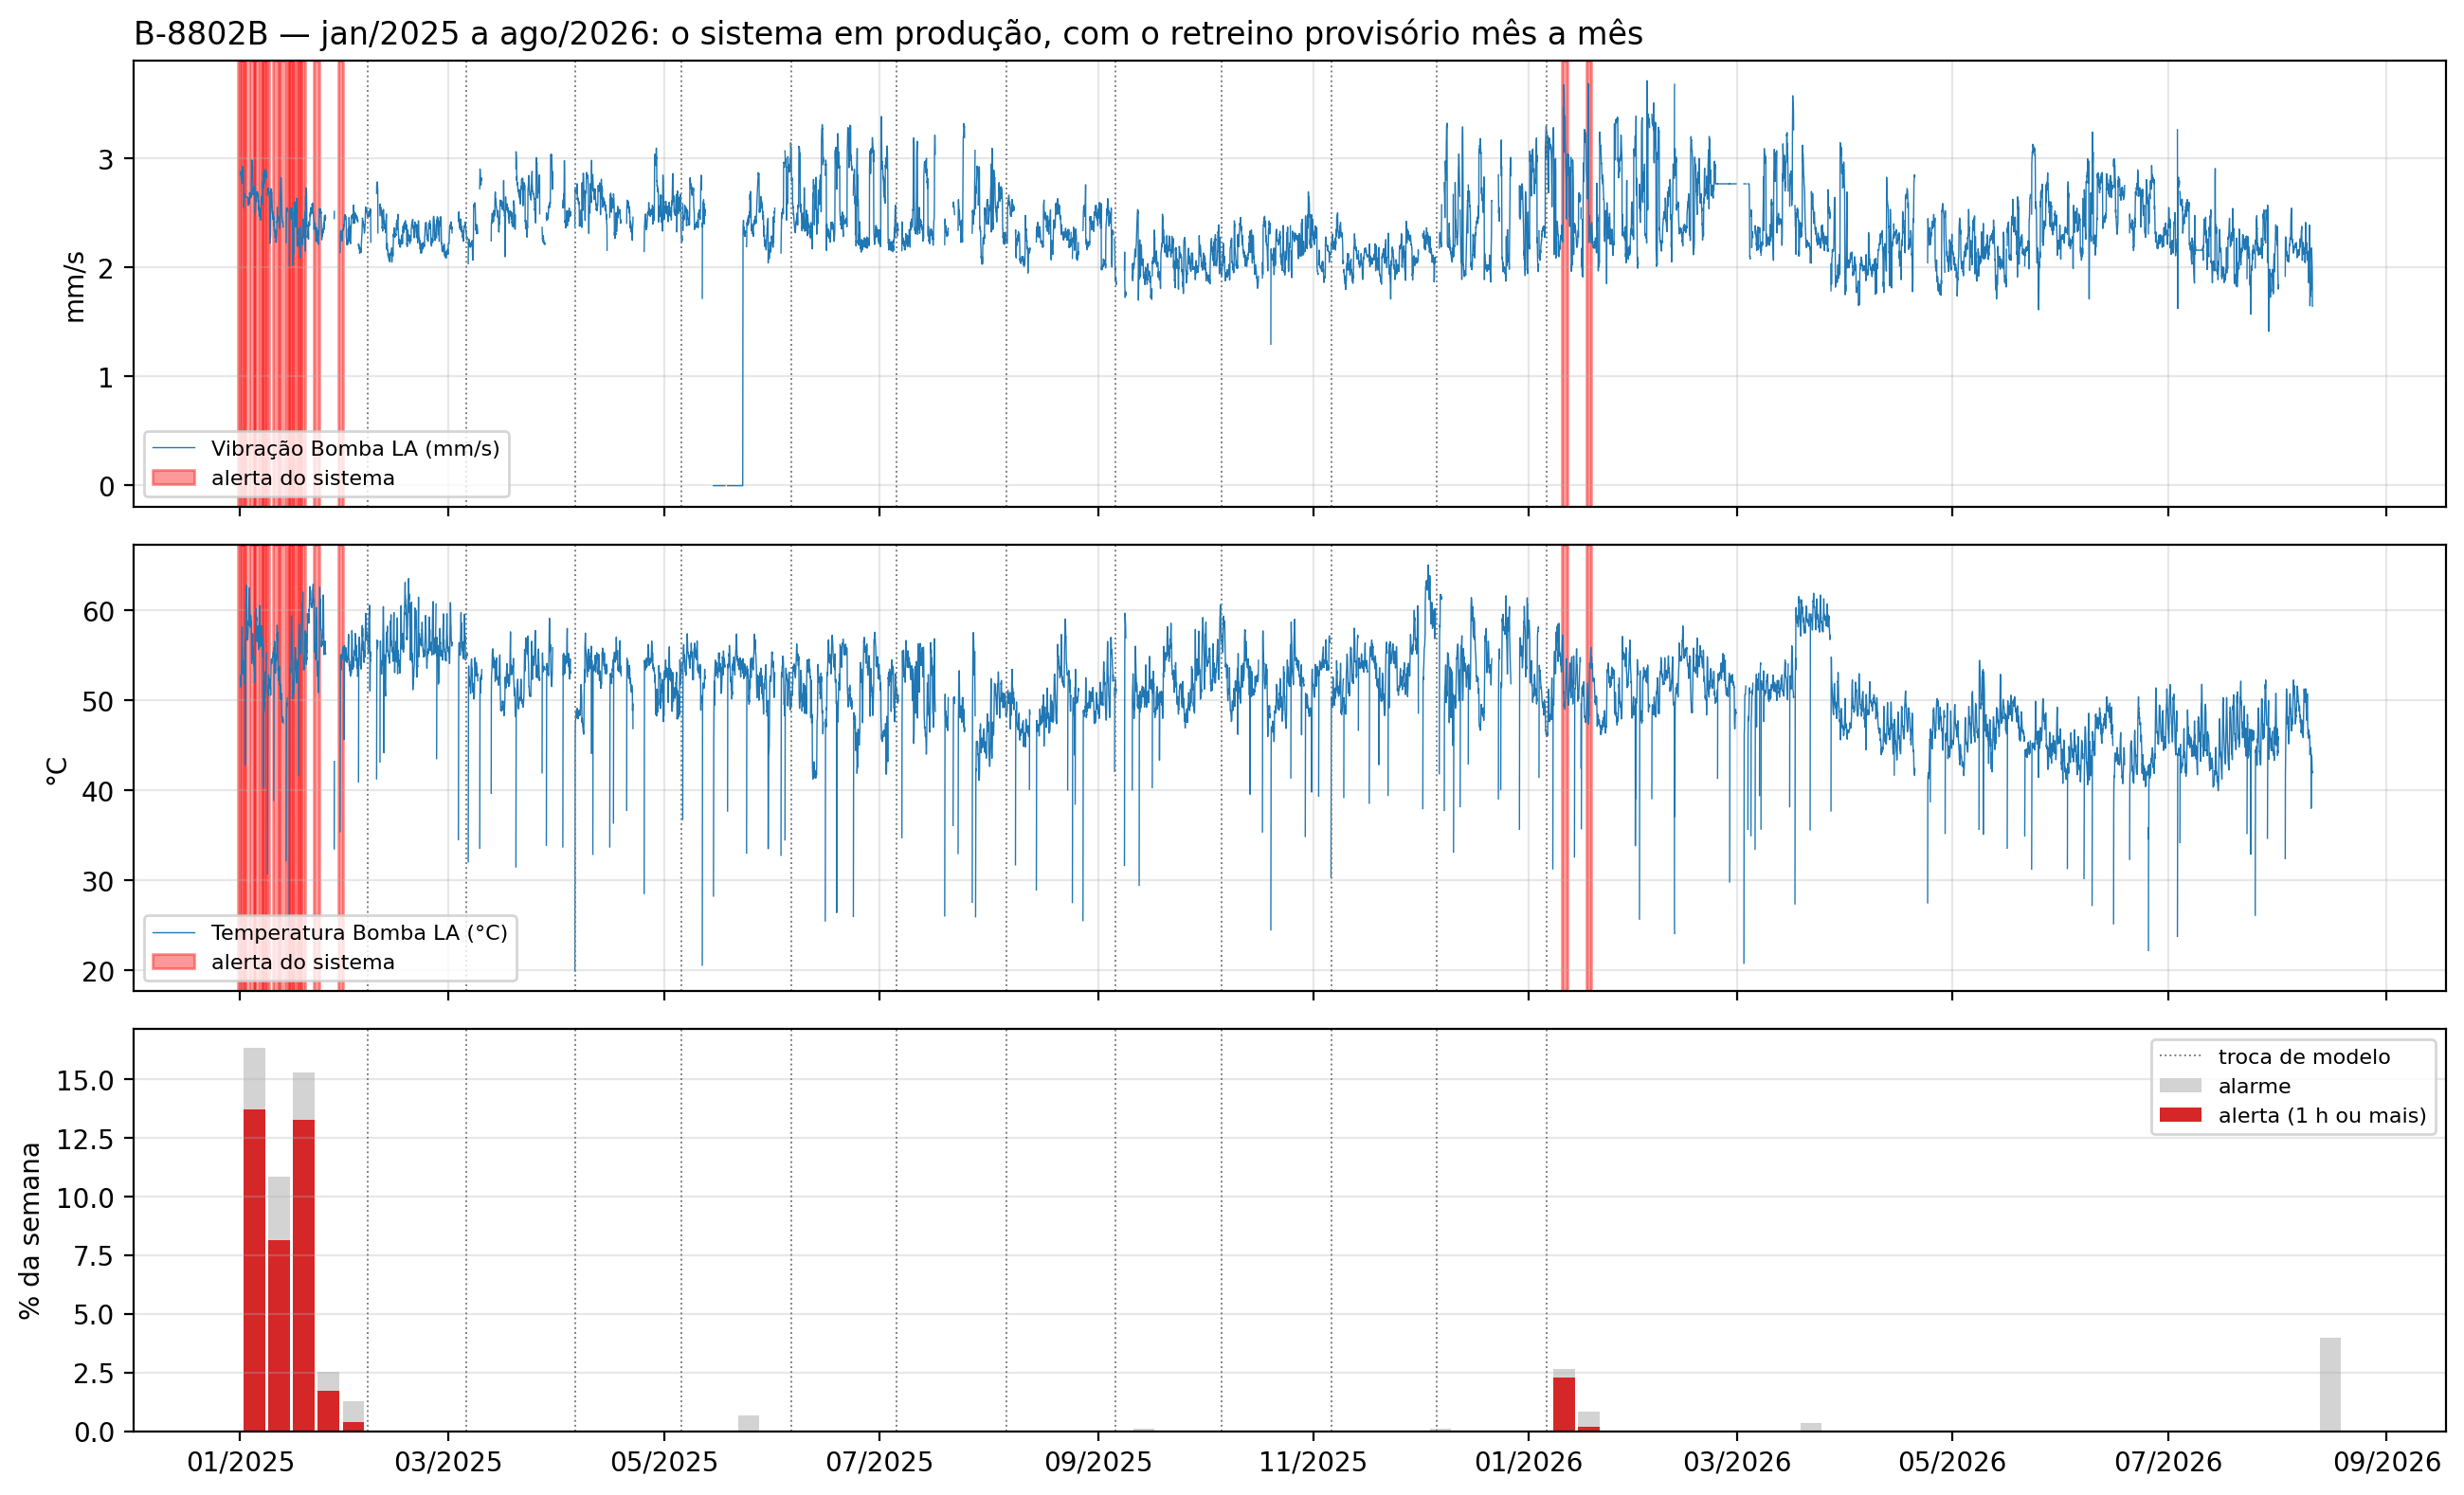

In [6]:
sem = prod.groupby(pd.Grouper(freq="W"))
alarme_sem, alerta_sem = 100 * sem["is_anomaly"].mean(), 100 * sem["alerta"].mean()
op = raw[raw["Pressão Descarga"] > 35]
h = op[["Vibração Bomba LA", "Temperatura Bomba LA"]].resample("1h").mean()
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True, gridspec_kw={"height_ratios": [1, 1, 0.9]})
for ax, c, u in zip(axes[:2], ["Vibração Bomba LA", "Temperatura Bomba LA"], ["mm/s", "°C"]):
    ax.plot(h.index, h[c], linewidth=0.5, color="tab:blue", label=f"{c} ({u})")
    for i, e in enumerate(eps):
        ax.axvspan(e["início"] - pd.Timedelta(hours=18), e["fim"] + pd.Timedelta(hours=18), color="red", alpha=0.4,
                   label="alerta do sistema" if i == 0 else None)
    ax.set_ylabel(u); ax.grid(alpha=0.3); ax.legend(loc="lower left", fontsize=8)
axes[2].bar(alarme_sem.index, alarme_sem.values, width=6, color="lightgray", label="alarme")
axes[2].bar(alerta_sem.index, alerta_sem.values, width=6, color="tab:red", label="alerta (1 h ou mais)")
for n, a in enumerate(agenda[1:]):
    for ax in axes: ax.axvline(a["ini"], color="gray", linewidth=0.7, linestyle=":", label=("troca de modelo" if (n == 0 and ax is axes[2]) else None))
axes[2].set_ylabel("% da semana"); axes[2].grid(alpha=0.3, axis="y"); axes[2].legend(loc="upper right", fontsize=8)
axes[0].set_title("B-8802B — jan/2025 a ago/2026: o sistema em produção, com o retreino provisório mês a mês", loc="left")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y")); plt.tight_layout(); plt.show()

## 6. Comparação: o pipeline contra o modelo antigo mantido e contra o modelo atual

Os mesmos dados (jan/2025 a ago/2026), três cenários, as mesmas regras de alarme. O modelo atual (B-8802B-2025) é uma
referência otimista: ele foi treinado com 2025 inteiro e escolhido olhando 2026.

In [7]:
def cenario(nome, bundle):
    r, err = roda(bundle, raw.index.min(), FIM)
    e = episodios(r["alerta"], err, nome)
    return ({"cenário": nome, "alarme (% do tempo)": round(100 * r["is_anomaly"].mean(), 2),
             "alerta (% do tempo)": round(100 * r["alerta"].mean(), 2), "episódios de alerta": len(e)},
            r["alerta"].groupby(pd.Grouper(freq="MS")).mean() * 100)

l_ant, m_ant = cenario("modelo de 2022 mantido (sem pipeline)", B_ANTIGO)
l_atu, m_atu = cenario("modelo atual B-8802B-2025 (referência)", B_ATUAL)
l_pip = {"cenário": "pipeline (provisórios + 12 meses)", "alarme (% do tempo)": round(100 * prod["is_anomaly"].mean(), 2),
         "alerta (% do tempo)": round(100 * prod["alerta"].mean(), 2), "episódios de alerta": len(eps_df)}
display(pd.DataFrame([l_ant, l_pip, l_atu]).set_index("cenário"))
tab = pd.DataFrame({l_ant["cenário"]: m_ant, l_pip["cenário"]: prod["alerta"].groupby(pd.Grouper(freq="MS")).mean() * 100,
                    l_atu["cenário"]: m_atu}).round(2)
tab.index = tab.index.strftime("%m/%Y"); tab.T.rename_axis("% do mês em alerta")

,alarme (% do tempo),alerta (% do tempo),episódios de alerta
cenário,,,
modelo de 2022 mantido (sem pipeline),14.42,12.02,269
pipeline (provisórios + 12 meses),0.58,0.45,16
modelo atual B-8802B-2025 (referência),0.02,0.00,1


datetime,01/2025,02/2025,03/2025,04/2025,05/2025,06/2025,07/2025,08/2025,09/2025,10/2025,11/2025,12/2025,01/2026,02/2026,03/2026,04/2026,05/2026,06/2026,07/2026,08/2026
% do mês em alerta,,,,,,,,,,,,,,,,,,,,
modelo de 2022 mantido (sem pipeline),8.17,0.25,7.21,5.69,8.13,30.29,23.67,3.92,0.93,1.53,2.23,16.1,20.89,27.58,17.86,3.46,11.44,24.82,15.44,2.72
pipeline (provisórios + 12 meses),8.17,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.56,0.00,0.00,0.00,0.00,0.00,0.00,0.00
modelo atual B-8802B-2025 (referência),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00


## 7. A sensibilidade de cada modelo que entrou em produção

Da bateria de cada etapa: a antecedência na falha real de 2022 (que nenhum modelo viu) e na falha sintética injetada
no último mês da janela de treino dele. O alarme no normal de 2022 é só informativo (2022 é o normal de antes do
reparo, outro conceito).

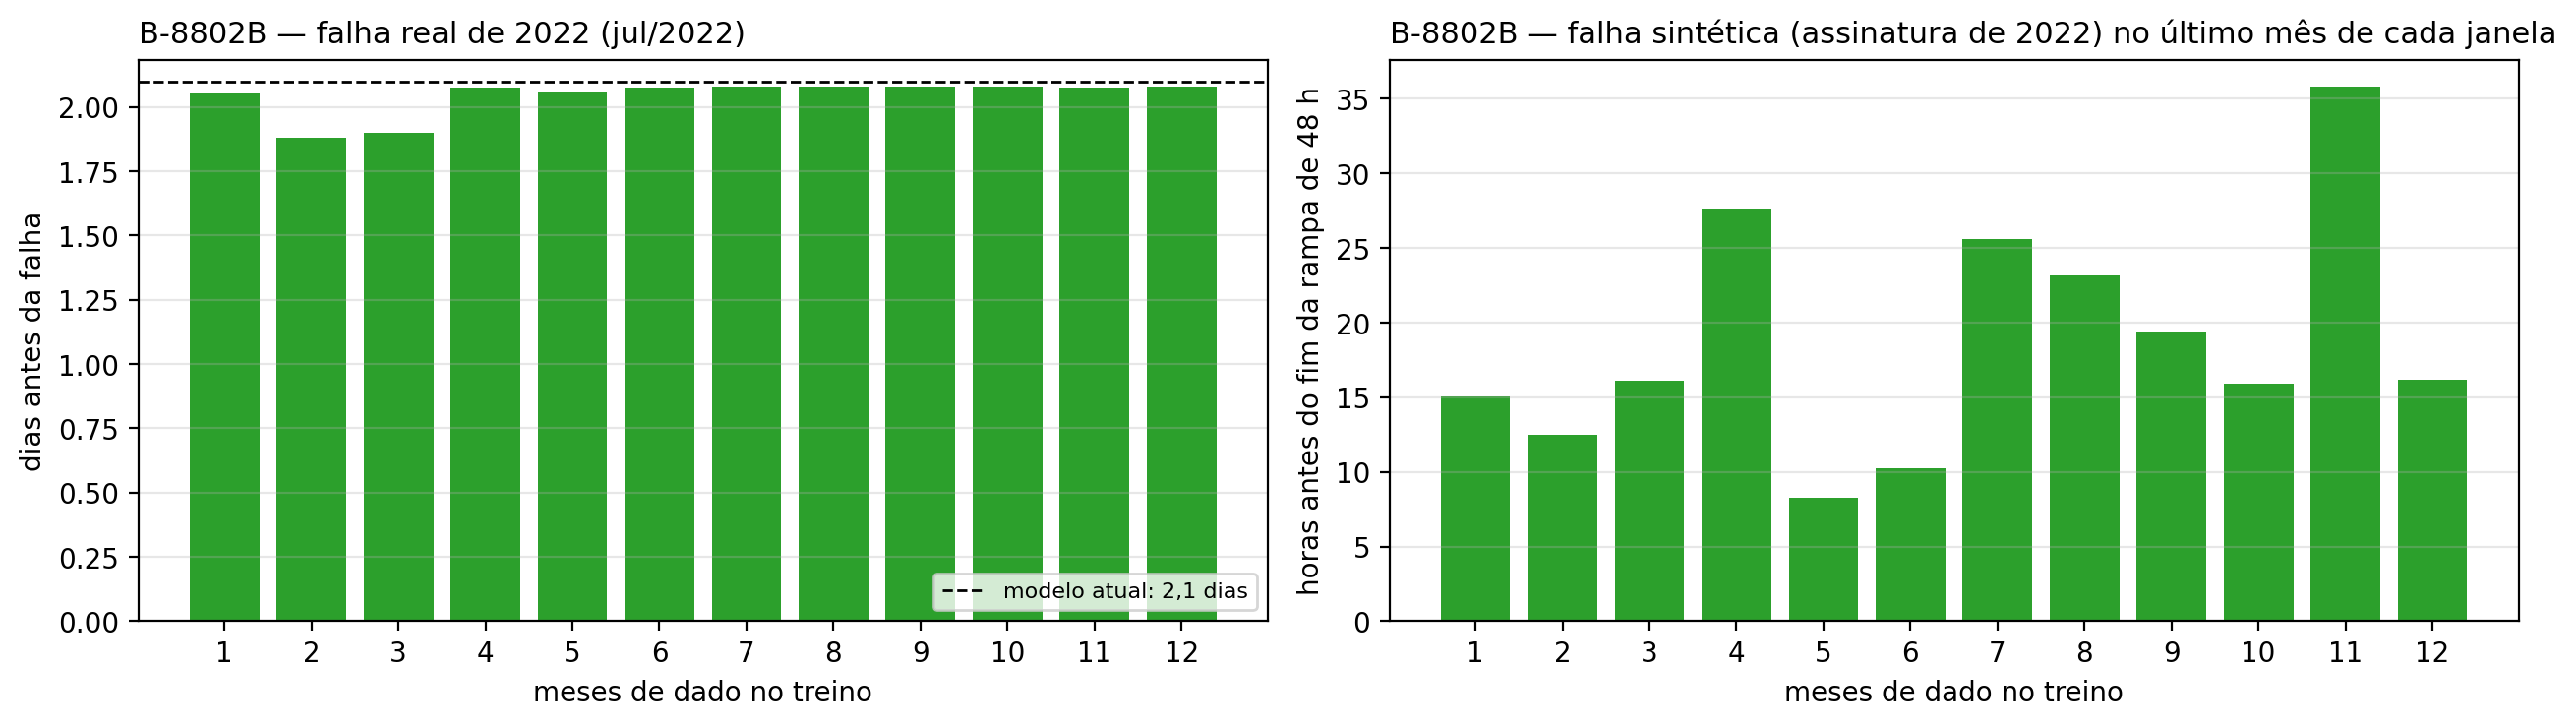

,treino_fim,aprovado,fp_val_pct,falha_2022_dias,sintetica_t0,sintetica_h,normal_2022_pct
etapa,,,,,,,
1,2025-02-06,True,0.0,2.05,2025-02-03 00:00:00,15.08,5.04
2,2025-03-06,True,0.0,1.88,2025-02-27 00:00:00,12.50,4.74
3,2025-04-06,True,0.0,1.90,2025-03-24 00:00:00,16.08,2.65
4,2025-05-06,True,0.0,2.08,2025-05-03 00:00:00,27.67,1.81
5,2025-06-06,True,0.0,2.06,2025-06-03 00:00:00,8.25,0.00
6,2025-07-06,True,0.0,2.08,2025-07-03 00:00:00,10.25,0.96
7,2025-08-06,True,0.0,2.08,2025-08-03 00:00:00,25.58,0.46
8,2025-09-06,True,0.0,2.08,2025-09-03 00:00:00,23.17,0.58
9,2025-10-06,True,0.0,2.08,2025-10-03 00:00:00,19.42,0.00


In [8]:
sens = resumo[["etapa", "treino_fim", "aprovado", "fp_val_pct", "falha_2022_dias", "sintetica_t0", "sintetica_h", "normal_2022_pct"]].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].bar(sens["etapa"], sens["falha_2022_dias"].fillna(0), color="tab:green")
axes[0].axhline(2.1, color="black", linestyle="--", linewidth=1, label="modelo atual: 2,1 dias")
axes[0].set_xlabel("meses de dado no treino"); axes[0].set_ylabel("dias antes da falha"); axes[0].legend(fontsize=8, loc="lower right")
axes[0].set_title("B-8802B — falha real de 2022 (jul/2022)", loc="left", fontsize=11)
axes[1].bar(sens["etapa"], sens["sintetica_h"].fillna(0).clip(lower=0), color="tab:green")
axes[1].set_xlabel("meses de dado no treino"); axes[1].set_ylabel("horas antes do fim da rampa de 48 h")
axes[1].set_title("B-8802B — falha sintética (assinatura de 2022) no último mês de cada janela", loc="left", fontsize=11)
for ax in axes: ax.grid(alpha=0.3, axis="y"); ax.set_xticks(sens["etapa"])
plt.tight_layout(); plt.show()
sens.round(2).set_index("etapa")

## 8. Avaliação

### Os números que resumem o replay

In [9]:
troca = agenda[1]["ini"]
antes, depois = prod[prod.index < troca], prod[prod.index >= troca]
e_dep = eps_df[eps_df["início"] >= troca]
print(f"modelo de 2022 em produção até {troca:%d/%m/%Y}: alerta em {100 * antes['alerta'].mean():.1f} % do tempo, "
      f"{(eps_df['início'] < troca).sum()} episódios (nenhuma falha no período)")
print(f"depois da 1ª troca ({troca:%d/%m/%Y} a {FIM:%d/%m/%Y}, {(FIM - troca).days} dias): alerta em "
      f"{100 * depois['alerta'].mean():.3f} % do tempo, {len(e_dep)} episódios:")
for e in e_dep.itertuples():
    print(f"   {e.início:%d/%m/%Y %H:%M}, {e._4} h de alerta, modelo {e.modelo}, sensor principal {e._5}")
print(f"falha real de 2022: todos os {int(resumo['aprovado'].sum())} modelos alertam entre "
      f"{resumo['falha_2022_dias'].min():.1f} e {resumo['falha_2022_dias'].max():.1f} dias antes")
print(f"falha sintética: entre {resumo['sintetica_h'].min():.0f} e {resumo['sintetica_h'].max():.0f} h antes do fim da rampa")

modelo de 2022 em produção até 06/02/2025: alerta em 6.8 % do tempo, 14 episódios (nenhuma falha no período)
depois da 1ª troca (06/02/2025 a 10/08/2026, 550 dias): alerta em 0.036 % do tempo, 2 episódios:
   10/01/2026 22:50, 3.7 h de alerta, modelo 12 meses, sensor principal Vibração Bomba LNA
   17/01/2026 22:45, 0.2 h de alerta, modelo 12 meses, sensor principal Vibração Bomba LA
falha real de 2022: todos os 12 modelos alertam entre 1.9 e 2.1 dias antes
falha sintética: entre 8 e 36 h antes do fim da rampa


### O que o replay mostra

**O que funcionou**
- **A mudança de conceito foi vista e tratada.** O monitor do modelo antigo disparou em 09/01/2025, via vibração do
  mancal LA. A partir de 06/02/2025 o pipeline pôs um modelo provisório em produção, todos os 12 aprovados pela
  bateria, e o modelo de 12 meses assumiu em 06/01/2026.
- **Quase nenhum alerta depois da troca.** Em 18 meses de modelos do pipeline, 2 episódios de alerta, ambos em jan/2026
  (veja a célula acima). O modelo antigo mantido daria alerta em 12 % do tempo, com 269 episódios, sem falha nenhuma.
- **A sensibilidade se manteve desde o 1º mês** nos testes da bateria: todos os modelos alertam ~2 dias antes da falha
  real de 2022 e detectam a falha sintética. O alarme no normal de 2022 (outro conceito) cai de 5 % para 0 % conforme
  o modelo acumula meses, o retrato da maturação.
- **O monitor fez o que devia em cada fase.** O M6 dispara em alguns meses provisórios (a referência ainda não cobre o
  ano, e o retreino seguinte a refaz); com o modelo de 12 meses, nenhum disparo em 2026. O **M8 pegou a mudança do
  mancal LA em 01/04/2026**, como no modelo atual. O M7 apontou os 4 períodos de dado congelado.

**O que precisa de atenção**
- **O mês entre o disparo e o 1º provisório.** De 01/01 a 06/02/2025 o modelo de 2022 seguiu em produção e gerou 14
  episódios de alerta (6,8 % do tempo), todos falsos. O monitor avisou em 09/01; a política manda tratar os alertas do
  modelo antigo com ressalva a partir daí, e isso precisa estar claro para a operação no período de quarentena.
- **10/01/2026:** um alerta de 3,7 h (vibração do mancal LNA) do modelo de 12 meses que o modelo atual não dá. É um
  candidato a verificar com a operação, como o de 17/01/2026.
- **Os testes de sensibilidade do provisório são otimistas.** A falha sintética é injetada no último mês da própria
  janela de treino, um período que o modelo conhece. O teste mais duro, em datas futuras, ficou no experimento
  acumulativo (`retreino_acumulativo_explicado_B-8802B.ipynb`), onde a detecção só ficou estável com ~8 meses.
- **O passo definitivo não foi exercitado.** No replay o modelo de 12 meses passou pela bateria provisória: em
  06/01/2026 ainda não existia o held-out que a bateria definitiva pede. Na prática ele entra como provisório e ganha a
  aprovação definitiva depois de alguns meses de dado novo (o modelo atual B-8802B-2025 foi escolhido assim, com
  jan–mai/2026).

**Conclusão.** De ponta a ponta, o pipeline transforma 12 % do tempo em alerta falso (modelo desatualizado) em 2
episódios em 18 meses, sem perder a detecção da falha de 2022 em nenhum mês, e o monitor sinaliza tanto a mudança de
2025 quanto a de 2026. O ponto fraco é o mês de quarentena, coberto pela política, e não pelo código.